# Smart Grid Energy Management — Q-Learning

**Module:** Machine Learning  
**Algorithm:** Q-Learning (Off-Policy Temporal Difference Control)  
**Dataset:** Energy Consumption, Generation, Prices & Weather (Spain) — Kaggle  
**Dataset URL:** https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather  

---

## Problem Statement

A smart grid agent must decide **when to buy, sell, or store energy** to minimise electricity cost while maintaining grid stability. The agent interacts with a simulated environment built from real Spanish electricity market data (2015–2018).

### Key Design Decisions
| Component | Design |
|---|---|
| **State** | (hour bin, price bin, battery bin, net-load bin) |
| **Actions** | 0 = Buy · 1 = Sell · 2 = Idle/Store |
| **Reward** | Net profit minus stability penalty |
| **Algorithm** | Q-Learning — off-policy, greedy target policy |


## 1. Imports & Reproducibility

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import random
import warnings
warnings.filterwarnings('ignore')

# ── Numerical / data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid')

print('All imports successful. Seed set to', SEED)

All imports successful. Seed set to 42


## 2. Dataset Loading & Exploration

**Download instructions (first-time setup):**
1. Go to https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather
2. Download and unzip the archive
3. Place `energy_dataset.csv` and `weather_features.csv` in the same folder as this notebook

The cell below loads both files and merges them on the `time` column.

In [2]:
# ── Load energy dataset ───────────────────────────────────────────────────────
ENERGY_FILE  = '../data/energy_dataset.csv'
WEATHER_FILE = '../data/weather_features.csv'

# Check files exist
for f in [ENERGY_FILE, WEATHER_FILE]:
    if not os.path.exists(f):
        raise FileNotFoundError(
            f"'{f}' not found. Please download from Kaggle and place in the notebook directory.\n"
            "URL: https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather"
        )

energy_df  = pd.read_csv(ENERGY_FILE,  parse_dates=['time'])
weather_df = pd.read_csv(WEATHER_FILE, parse_dates=['dt_iso'])

print('Energy dataset shape :', energy_df.shape)
print('Weather dataset shape:', weather_df.shape)
energy_df.head(3)

Energy dataset shape : (35064, 29)
Weather dataset shape: (178396, 17)


,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48


In [3]:
weather_agg = (
    weather_df
    .rename(columns={'dt_iso': 'time'})
    .groupby('time')[['temp', 'wind_speed', 'clouds_all']]
    .mean()
    .reset_index()
)

# Fix timezone-aware timestamps from Kaggle dataset → strip tz, keep as naive datetime
energy_df['time'] = pd.to_datetime(energy_df['time'], utc=True).dt.tz_localize(None)
weather_agg['time'] = pd.to_datetime(weather_agg['time'], utc=True).dt.tz_localize(None)

# Merge on time
df = energy_df.merge(weather_agg, on='time', how='left')

# Select core columns
core_cols = [
    'time',
    'price actual',            # Actual electricity price (€/MWh)
    'total load actual',       # Actual electricity demand (MW)
    'generation solar',        # Solar generation (MW)
    'generation wind onshore', # Wind generation (MW)
    'temp',                    # Temperature (K)
]
df = df[core_cols].copy()
df.columns = ['time', 'price', 'load', 'solar', 'wind', 'temp']

# Drop rows with missing critical values
df.dropna(subset=['price', 'load'], inplace=True)

# Fill remaining NaNs with column median
df.fillna(df.median(numeric_only=True), inplace=True)

# Compute net renewable generation and net load
df['renewable_gen'] = df['solar'] + df['wind']
df['net_load']      = df['load'] - df['renewable_gen']

# Extract hour of day — guaranteed to work now that 'time' is tz-naive datetime
df['hour'] = df['time'].dt.hour

# Clip negative net_load to 0 (excess renewable → can be stored/sold)
df['net_load'] = df['net_load'].clip(lower=0)

df.reset_index(drop=True, inplace=True)

print('Final dataset shape:', df.shape)
print('Date range:', df['time'].min(), '→', df['time'].max())
df.describe().round(2)

Final dataset shape: (35028, 9)
Date range: 2014-12-31 23:00:00 → 2018-12-31 22:00:00


,time,price,load,solar,wind,temp,renewable_gen,net_load,hour
count,35028,35028.00,35028.00,35028.00,35028.00,35028.00,35028.00,35028.00,35028.00
mean,2016-12-31 22:10:03.597122,57.89,28696.94,1432.74,5465.77,289.68,6898.51,21798.43,11.50
min,2014-12-31 23:00:00,9.33,18041.00,0.00,0.00,271.94,0.00,6707.00,0.00
25%,2016-01-01 22:45:00,49.36,24807.75,71.00,2935.00,284.06,4342.00,18300.00,5.00
50%,2017-01-01 00:30:00,58.02,28901.00,616.00,4850.00,289.03,6545.00,21683.00,11.50
75%,2017-12-31 23:15:00,68.00,32192.00,2578.00,7398.25,295.09,8945.25,25452.25,18.00
max,2018-12-31 22:00:00,116.80,41015.00,5792.00,17436.00,309.27,19524.00,37276.00,23.00
std,NaN,14.19,4574.99,1680.19,3213.31,7.26,3368.26,5001.03,6.92


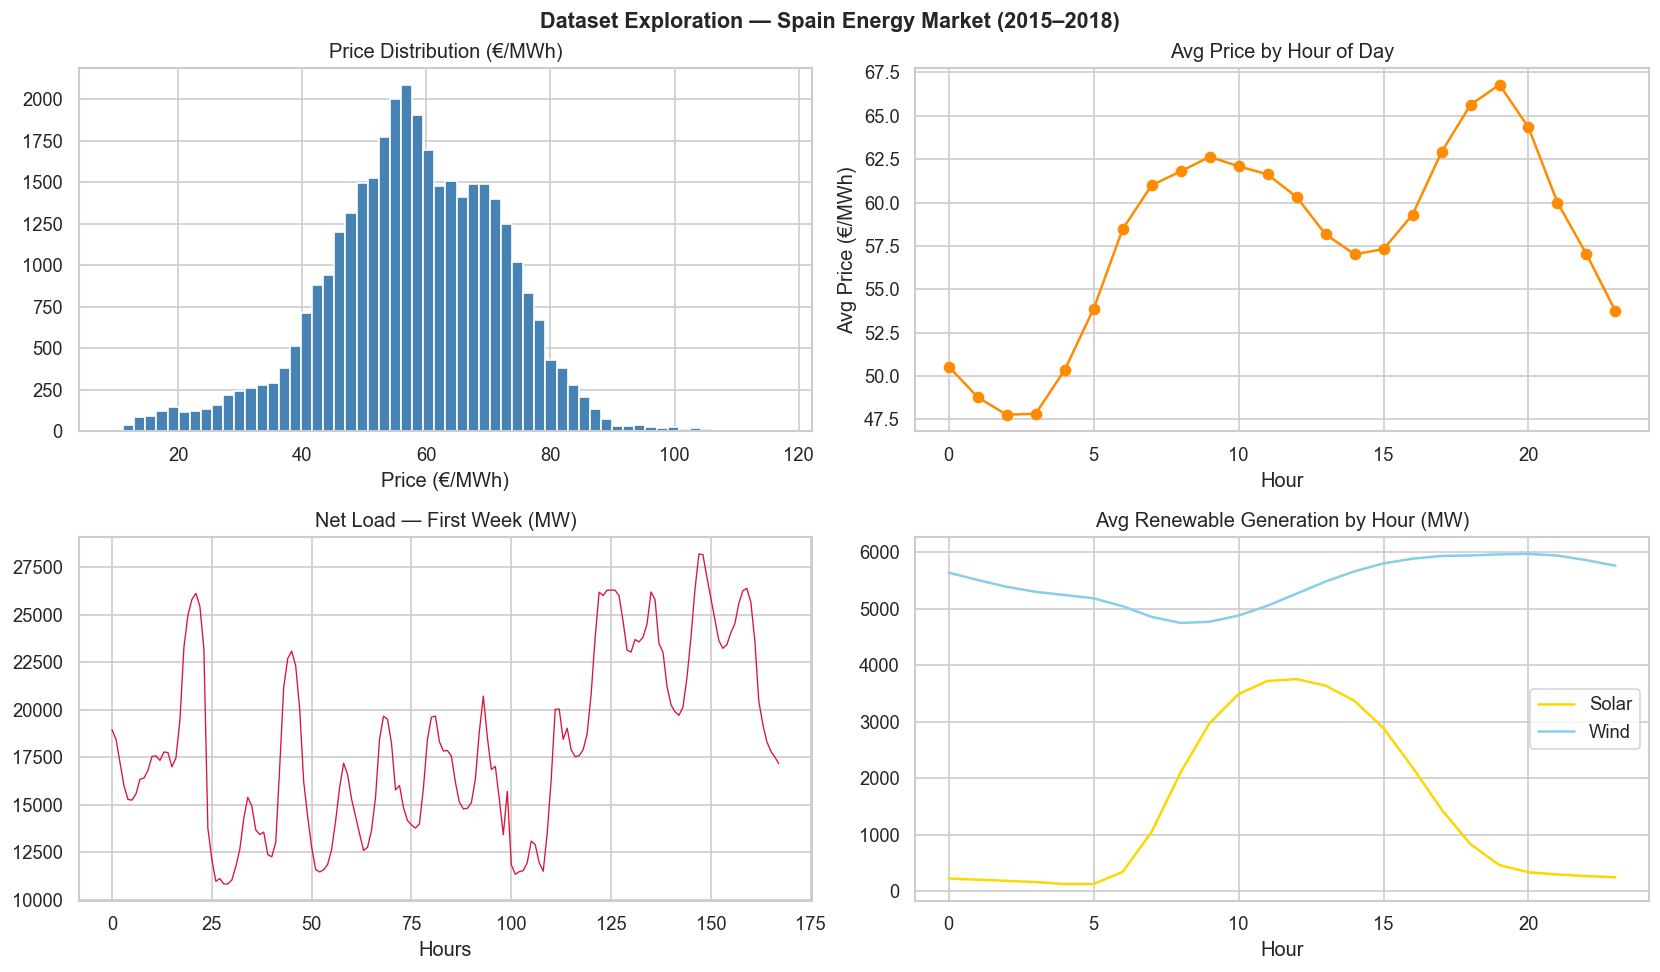

EDA plot saved as eda_plots.png


In [4]:
# ── Exploratory plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Price distribution
axes[0, 0].hist(df['price'], bins=60, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Price Distribution (€/MWh)')
axes[0, 0].set_xlabel('Price (€/MWh)')

# Average price by hour
hourly_price = df.groupby('hour')['price'].mean()
axes[0, 1].plot(hourly_price.index, hourly_price.values, marker='o', color='darkorange')
axes[0, 1].set_title('Avg Price by Hour of Day')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Avg Price (€/MWh)')

# Net load over sample week
sample = df.iloc[:168]   # first week
axes[1, 0].plot(sample['net_load'].values, color='crimson', linewidth=0.8)
axes[1, 0].set_title('Net Load — First Week (MW)')
axes[1, 0].set_xlabel('Hours')

# Solar vs Wind generation
axes[1, 1].plot(df.groupby('hour')['solar'].mean(), label='Solar', color='gold')
axes[1, 1].plot(df.groupby('hour')['wind'].mean(),  label='Wind',  color='skyblue')
axes[1, 1].set_title('Avg Renewable Generation by Hour (MW)')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].legend()

plt.tight_layout()
plt.suptitle('Dataset Exploration — Spain Energy Market (2015–2018)', y=1.01, fontsize=13, fontweight='bold')
plt.savefig('../outputs/eda_plots.png', bbox_inches='tight')
plt.show()
print('EDA plot saved as eda_plots.png')

## 3. Smart Grid Environment

We design a **tabular RL environment** that discretises the continuous state space into bins, enabling Q-table learning without neural networks.

### State Space
| Dimension | Description | Bins |
|---|---|---|
| `hour_bin` | Time of day category (off-peak / shoulder / peak) | 4 |
| `price_bin` | Electricity price (low / medium / high) | 3 |
| `battery_bin` | Battery state-of-charge (0–100 kWh) | 5 |
| `net_load_bin` | Residual demand (low / medium / high) | 3 |

Total discrete states: **4 × 3 × 5 × 3 = 180**

### Action Space
| Action | Description |
|---|---|
| 0 — Buy | Purchase 10 MWh from grid at current price |
| 1 — Sell | Sell 10 MWh back to grid at current price |
| 2 — Idle | Do nothing / maintain state |

### Reward Function
```
reward = revenue - cost - stability_penalty
       = (sell_amount × price) - (buy_amount × price) - λ × |net_load|
```

In [5]:
class SmartGridEnv:
    """
    Tabular Reinforcement Learning environment for smart grid energy management.

    The agent observes a discretised state (hour, price, battery SoC, net load)
    and chooses to BUY, SELL, or remain IDLE each timestep.
    """

    # ── Constants ─────────────────────────────────────────────────────────────
    BATTERY_CAPACITY = 100.0   # kWh
    TRADE_AMOUNT     = 10.0    # MWh per action (buy or sell)
    LAMBDA_STABILITY = 0.05    # Penalty weight for unmet load

    N_HOUR_BINS    = 4
    N_PRICE_BINS   = 3
    N_BATTERY_BINS = 5
    N_LOAD_BINS    = 3
    N_ACTIONS      = 3         # 0=buy, 1=sell, 2=idle

    def __init__(self, dataframe: pd.DataFrame):
        """
        Parameters
        ----------
        dataframe : pd.DataFrame
            Preprocessed dataset with columns: hour, price, net_load
        """
        self.df   = dataframe.reset_index(drop=True)
        self.n_steps = len(self.df)

        # Pre-compute bin edges from dataset percentiles
        self._price_edges    = np.percentile(self.df['price'],    [33, 66])
        self._net_load_edges = np.percentile(self.df['net_load'], [33, 66])

        # Hour-of-day bins: [0-5]=night, [6-11]=morning, [12-17]=afternoon, [18-23]=evening
        self._hour_edges = [6, 12, 18]

        # Battery edges (0–100 kWh split into 5 equal bins)
        self._battery_edges = np.linspace(0, self.BATTERY_CAPACITY, self.N_BATTERY_BINS + 1)[1:-1]

        self.reset()

    # ── State Discretisation ──────────────────────────────────────────────────
    def _discretise(self, hour: int, price: float, battery: float, net_load: float) -> tuple:
        """Convert continuous features into discrete state tuple."""
        h_bin  = int(np.digitize(hour,      self._hour_edges))           # 0-3
        p_bin  = int(np.digitize(price,     self._price_edges))          # 0-2
        b_bin  = int(np.digitize(battery,   self._battery_edges))        # 0-4
        nl_bin = int(np.digitize(net_load,  self._net_load_edges))       # 0-2
        return (h_bin, p_bin, b_bin, nl_bin)

    # ── Environment API ───────────────────────────────────────────────────────
    def reset(self) -> tuple:
        """Reset environment to the first timestep; return initial state."""
        self.t       = 0
        self.battery = self.BATTERY_CAPACITY / 2.0   # start at 50% SoC
        self.total_cost   = 0.0
        self.total_reward = 0.0
        return self._get_state()

    def _get_state(self) -> tuple:
        """Return current discretised state."""
        row = self.df.iloc[self.t]
        return self._discretise(row['hour'], row['price'], self.battery, row['net_load'])

    def step(self, action: int):
        """
        Execute one timestep.

        Parameters
        ----------
        action : int  — 0=Buy, 1=Sell, 2=Idle

        Returns
        -------
        next_state : tuple
        reward     : float
        done       : bool
        info       : dict
        """
        row       = self.df.iloc[self.t]
        price     = row['price']
        net_load  = row['net_load']
        reward    = 0.0

        if action == 0:   # BUY — purchase energy, charge battery
            cost = price * self.TRADE_AMOUNT
            self.battery = min(self.battery + self.TRADE_AMOUNT, self.BATTERY_CAPACITY)
            reward = -cost
            self.total_cost += cost

        elif action == 1:  # SELL — discharge battery, earn revenue
            if self.battery >= self.TRADE_AMOUNT:
                revenue = price * self.TRADE_AMOUNT
                self.battery -= self.TRADE_AMOUNT
                reward = revenue
            else:
                reward = -5.0   # Penalty: cannot sell if battery empty

        else:              # IDLE
            reward = 0.0

        # Stability penalty: proportional to unmet net load
        stability_penalty = self.LAMBDA_STABILITY * net_load
        reward -= stability_penalty

        self.total_reward += reward
        self.t += 1
        done = self.t >= self.n_steps
        next_state = self._get_state() if not done else (0, 0, 0, 0)

        info = {
            'price'     : price,
            'battery'   : self.battery,
            'net_load'  : net_load,
            'total_cost': self.total_cost,
        }
        return next_state, reward, done, info

    @property
    def state_shape(self) -> tuple:
        return (self.N_HOUR_BINS, self.N_PRICE_BINS, self.N_BATTERY_BINS, self.N_LOAD_BINS)

print('SmartGridEnv class defined successfully.')

SmartGridEnv class defined successfully.


## 4. Q-Learning Algorithm

**Q-Learning** is an *off-policy* TD control method. It learns the optimal action-value function $Q^*(s, a)$ independently of the policy being followed.

### Update Rule

$$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \left[ r_{t+1} + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t) \right]$$

Where:
- $\alpha$ = learning rate
- $\gamma$ = discount factor  
- $\varepsilon$ = exploration rate (decays over time)

**Key insight:** The target uses $\max_{a'} Q(s',a')$ — the *best* possible next action — making it off-policy (greedy target regardless of what the agent actually does).

In [6]:
class QLearningAgent:
    """
    Tabular Q-Learning agent with epsilon-greedy exploration.

    The Q-table maps every (state, action) pair to an expected cumulative
    reward.  Updates are off-policy: the target always uses the greedy
    (max) action, regardless of which action was actually taken.
    """

    def __init__(
        self,
        state_shape : tuple,
        n_actions   : int,
        alpha       : float = 0.10,   # Learning rate
        gamma       : float = 0.95,   # Discount factor
        epsilon     : float = 1.0,    # Initial exploration rate
        epsilon_min : float = 0.05,   # Minimum exploration rate
        epsilon_decay: float = 0.995, # Multiplicative decay per episode
    ):
        self.alpha         = alpha
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.n_actions     = n_actions

        # Initialise Q-table with zeros
        self.q_table = np.zeros(state_shape + (n_actions,), dtype=np.float64)
        print(f'Q-table shape: {self.q_table.shape}  '
              f'({self.q_table.size} entries)')

    # ── Action selection ──────────────────────────────────────────────────────
    def select_action(self, state: tuple) -> int:
        """
        Epsilon-greedy action selection.
        With probability ε → random action (exploration)
        With probability 1-ε → greedy action (exploitation)
        """
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)   # Explore
        return int(np.argmax(self.q_table[state]))      # Exploit

    # ── Q-Learning update ─────────────────────────────────────────────────────
    def update(
        self,
        state      : tuple,
        action     : int,
        reward     : float,
        next_state : tuple,
        done       : bool,
    ) -> float:
        """
        Apply the Q-Learning Bellman update (off-policy).

        Returns the TD error for diagnostics.
        """
        current_q = self.q_table[state][action]

        # Off-policy target: use best Q-value in next state
        if done:
            target_q = reward
        else:
            target_q = reward + self.gamma * np.max(self.q_table[next_state])

        td_error = target_q - current_q
        self.q_table[state][action] += self.alpha * td_error
        return td_error

    def decay_epsilon(self):
        """Decay exploration rate after each episode."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

print('QLearningAgent class defined.')

QLearningAgent class defined.


## 5. Training

In [7]:
# ── Train / Test split ────────────────────────────────────────────────────────
# Use first 80% of data for training, remaining 20% for evaluation
split_idx   = int(len(df) * 0.80)
train_df    = df.iloc[:split_idx].reset_index(drop=True)
test_df     = df.iloc[split_idx:].reset_index(drop=True)

print(f'Training rows : {len(train_df):,}  ({train_df["time"].min()} → {train_df["time"].max()})')
print(f'Testing  rows : {len(test_df):,}  ({test_df["time"].min()} → {test_df["time"].max()})')

# ── Initialise environment & agent ────────────────────────────────────────────
env_train = SmartGridEnv(train_df)

agent_ql = QLearningAgent(
    state_shape   = env_train.state_shape,
    n_actions     = env_train.N_ACTIONS,
    alpha         = 0.10,
    gamma         = 0.95,
    epsilon       = 1.0,
    epsilon_min   = 0.05,
    epsilon_decay = 0.995,
)

Training rows : 28,022  (2014-12-31 23:00:00 → 2018-03-14 22:00:00)
Testing  rows : 7,006  (2018-03-14 23:00:00 → 2018-12-31 22:00:00)
Q-table shape: (4, 3, 5, 3, 3)  (540 entries)


In [ ]:
# ── Training loop ─────────────────────────────────────────────────────────────
N_EPISODES       = 200          # Full passes over training data
episode_rewards  = []           # Total reward per episode
episode_costs    = []           # Total cost per episode
epsilon_history  = []           # Epsilon tracking
td_error_history = []           # Mean |TD error| per episode

print(f'Training Q-Learning for {N_EPISODES} episodes...\n')

for episode in range(1, N_EPISODES + 1):
    state     = env_train.reset()
    ep_reward = 0.0
    ep_td     = []

    while True:
        # Choose action (epsilon-greedy)
        action = agent_ql.select_action(state)

        # Execute action in environment
        next_state, reward, done, info = env_train.step(action)

        # Q-Learning update
        td_err = agent_ql.update(state, action, reward, next_state, done)
        ep_td.append(abs(td_err))

        ep_reward += reward
        state      = next_state

        if done:
            break

    # Decay exploration after each episode
    agent_ql.decay_epsilon()

    episode_rewards.append(ep_reward)
    episode_costs.append(info['total_cost'])
    epsilon_history.append(agent_ql.epsilon)
    td_error_history.append(np.mean(ep_td))

    if episode % 25 == 0:
        print(f'  Episode {episode:>4}/{N_EPISODES}  |  '
              f'Reward: {ep_reward:>10.1f}  |  '
              f'ε = {agent_ql.epsilon:.4f}  |  '
              f'Mean |TD| = {np.mean(ep_td):.4f}')

print('\nTraining complete!')

Training Q-Learning for 200 episodes...

  Episode   25/200  |  Reward: -30487620.3  |  ε = 0.8822  |  Mean |TD| = 440.2640
  Episode   50/200  |  Reward: -30450199.4  |  ε = 0.7783  |  Mean |TD| = 456.6995
  Episode   75/200  |  Reward: -30451707.6  |  ε = 0.6866  |  Mean |TD| = 454.2502
  Episode  100/200  |  Reward: -30457885.2  |  ε = 0.6058  |  Mean |TD| = 453.2278


## 6. Training Diagnostics

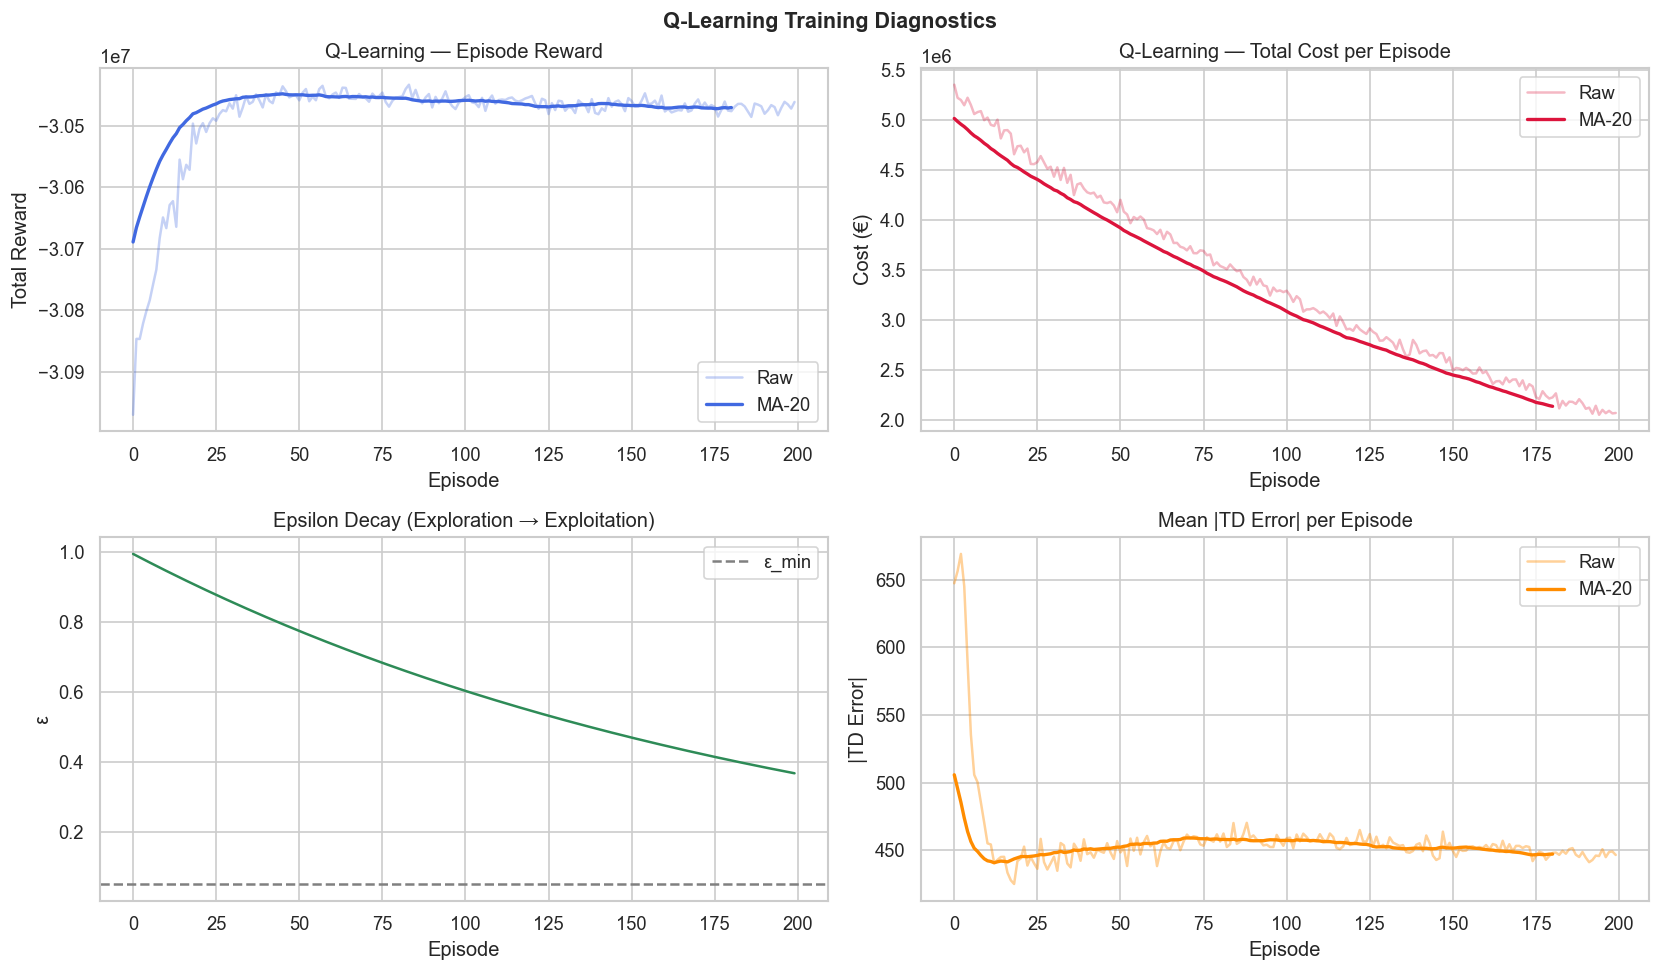

Training diagnostics saved as ql_training.png


In [ ]:
# ── Smoothing helper ──────────────────────────────────────────────────────────
def moving_avg(data, window=20):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Reward curve
axes[0, 0].plot(episode_rewards, alpha=0.3, color='royalblue', label='Raw')
axes[0, 0].plot(moving_avg(episode_rewards, 20), color='royalblue', linewidth=2, label='MA-20')
axes[0, 0].set_title('Q-Learning — Episode Reward')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Reward')
axes[0, 0].legend()

# Cost curve
axes[0, 1].plot(episode_costs, alpha=0.3, color='crimson', label='Raw')
axes[0, 1].plot(moving_avg(episode_costs, 20), color='crimson', linewidth=2, label='MA-20')
axes[0, 1].set_title('Q-Learning — Total Cost per Episode')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Cost (€)')
axes[0, 1].legend()

# Epsilon decay
axes[1, 0].plot(epsilon_history, color='seagreen')
axes[1, 0].set_title('Epsilon Decay (Exploration → Exploitation)')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('ε')
axes[1, 0].axhline(0.05, color='grey', linestyle='--', label='ε_min')
axes[1, 0].legend()

# TD error
axes[1, 1].plot(td_error_history, alpha=0.4, color='darkorange', label='Raw')
axes[1, 1].plot(moving_avg(td_error_history, 20), color='darkorange', linewidth=2, label='MA-20')
axes[1, 1].set_title('Mean |TD Error| per Episode')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('|TD Error|')
axes[1, 1].legend()

plt.tight_layout()
plt.suptitle('Q-Learning Training Diagnostics', y=1.01, fontsize=13, fontweight='bold')
plt.savefig('../outputs/ql_training.png', bbox_inches='tight')
plt.show()
print('Training diagnostics saved as ql_training.png')

## 7. Evaluation on Test Set

In [ ]:
def evaluate_agent(agent, env, greedy=True, label='Agent'):
    """
    Run one full episode on environment; return metrics dict.

    Parameters
    ----------
    greedy : bool — if True, agent always takes argmax(Q) (no exploration)
    """
    state = env.reset()
    total_reward  = 0.0
    total_cost    = 0.0
    action_counts = [0, 0, 0]      # [buy, sell, idle]
    rewards_list  = []
    battery_list  = []

    saved_eps = agent.epsilon
    if greedy:
        agent.epsilon = 0.0        # Disable exploration

    while True:
        action = agent.select_action(state)
        next_state, reward, done, info = env.step(action)

        total_reward += reward
        action_counts[action] += 1
        rewards_list.append(reward)
        battery_list.append(info['battery'])
        total_cost = info['total_cost']
        state = next_state

        if done:
            break

    agent.epsilon = saved_eps       # Restore epsilon

    metrics = {
        'label'         : label,
        'total_reward'  : total_reward,
        'total_cost'    : total_cost,
        'mean_reward'   : np.mean(rewards_list),
        'std_reward'    : np.std(rewards_list),
        'action_dist'   : {
            'buy'  : action_counts[0],
            'sell' : action_counts[1],
            'idle' : action_counts[2],
        },
        'rewards_list'  : rewards_list,
        'battery_list'  : battery_list,
    }
    return metrics


# ── Evaluate Q-Learning on test set ───────────────────────────────────────────
env_test = SmartGridEnv(test_df)
ql_metrics = evaluate_agent(agent_ql, env_test, greedy=True, label='Q-Learning')

print('=== Q-Learning Test Results ===')
print(f'  Total Reward   : {ql_metrics["total_reward"]:>12.2f}')
print(f'  Total Cost (€) : {ql_metrics["total_cost"]:>12.2f}')
print(f'  Mean Reward/step: {ql_metrics["mean_reward"]:>11.4f}')
print(f'  Std  Reward/step: {ql_metrics["std_reward"]:>11.4f}')
print(f'  Action Distribution:')
for k, v in ql_metrics['action_dist'].items():
    pct = v / len(ql_metrics['rewards_list']) * 100
    print(f'    {k.capitalize():6s}: {v:>6,}  ({pct:.1f}%)')

=== Q-Learning Test Results ===
  Total Reward   :  -7772536.05
  Total Cost (€) :     23592.40
  Mean Reward/step:  -1109.4114
  Std  Reward/step:    251.0715
  Action Distribution:
    Buy   :     42  (0.6%)
    Sell  :  5,792  (82.7%)
    Idle  :  1,172  (16.7%)


In [ ]:
# ── Baseline: Random agent ─────────────────────────────────────────────────────
class RandomAgent:
    """Uniformly random baseline agent."""
    def __init__(self, n_actions):
        self.n_actions = n_actions
        self.epsilon   = 0.0   # Dummy attribute for compatibility with evaluate_agent

    def select_action(self, state):
        return np.random.randint(self.n_actions)

random_agent  = RandomAgent(n_actions=3)
env_test_rand = SmartGridEnv(test_df)
rand_metrics  = evaluate_agent(random_agent, env_test_rand, greedy=False, label='Random')

print('=== Random Baseline Results ===')
print(f'  Total Reward   : {rand_metrics["total_reward"]:>12.2f}')
print(f'  Total Cost (€) : {rand_metrics["total_cost"]:>12.2f}')
print(f'  Mean Reward/step: {rand_metrics["mean_reward"]:>11.4f}')

=== Random Baseline Results ===
  Total Reward   :  -7838382.35
  Total Cost (€) :   1465989.50
  Mean Reward/step:  -1118.8099


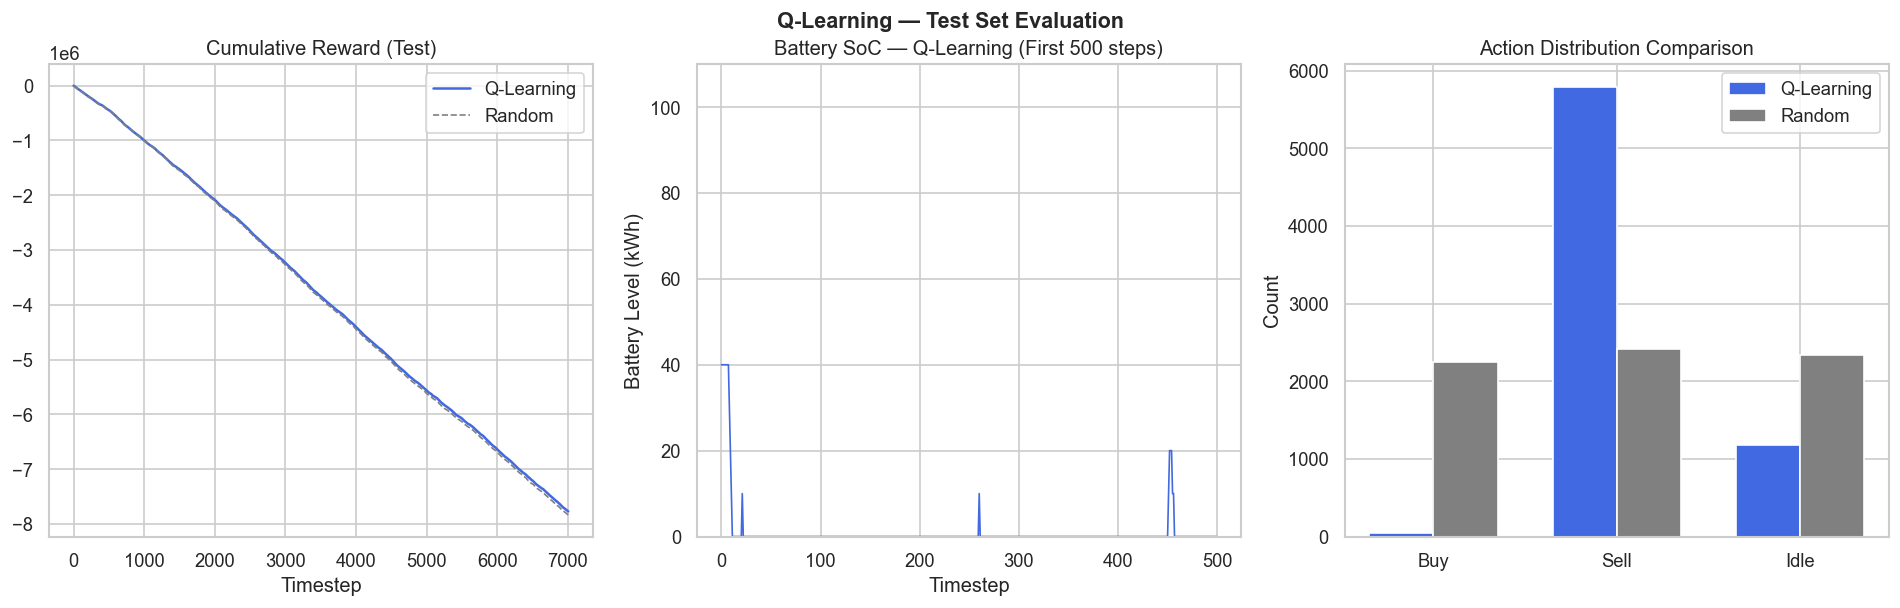

Evaluation plots saved as ql_evaluation.png


In [ ]:
# ── Comparison plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Cumulative reward comparison
cum_ql   = np.cumsum(ql_metrics['rewards_list'])
cum_rand = np.cumsum(rand_metrics['rewards_list'])
axes[0].plot(cum_ql,   label='Q-Learning', color='royalblue', linewidth=1.5)
axes[0].plot(cum_rand, label='Random',     color='grey',      linestyle='--', linewidth=1)
axes[0].set_title('Cumulative Reward (Test)')
axes[0].set_xlabel('Timestep')
axes[0].legend()

# Battery SoC profile
axes[1].plot(ql_metrics['battery_list'][:500],   color='royalblue', linewidth=1)
axes[1].set_title('Battery SoC — Q-Learning (First 500 steps)')
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Battery Level (kWh)')
axes[1].set_ylim(0, 110)

# Action distribution
labels = ['Buy', 'Sell', 'Idle']
ql_acts   = list(ql_metrics['action_dist'].values())
rand_acts = list(rand_metrics['action_dist'].values())
x = np.arange(3)
w = 0.35
axes[2].bar(x - w/2, ql_acts,   width=w, label='Q-Learning', color='royalblue')
axes[2].bar(x + w/2, rand_acts, width=w, label='Random',     color='grey')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].set_title('Action Distribution Comparison')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.suptitle('Q-Learning — Test Set Evaluation', y=1.01, fontsize=13, fontweight='bold')
plt.savefig('../outputs/ql_evaluation.png', bbox_inches='tight')
plt.show()
print('Evaluation plots saved as ql_evaluation.png')

## 8. Q-Table Visualisation

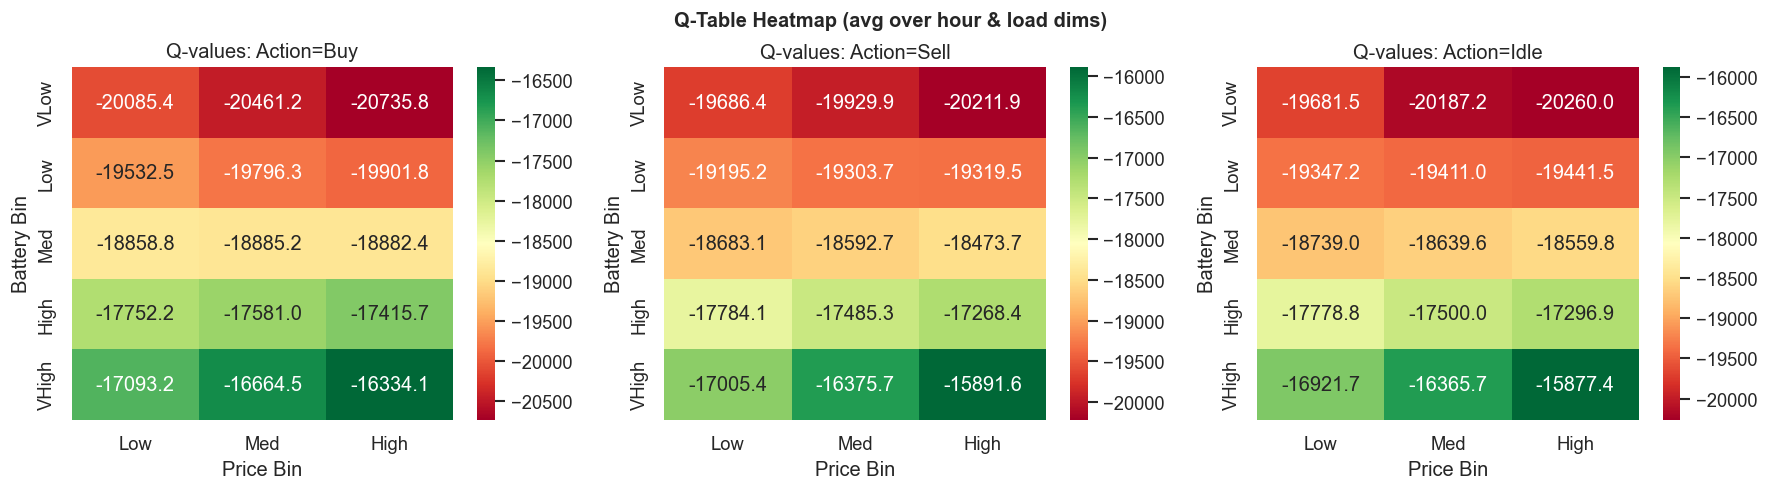

Q-table heatmap saved as ql_qtable.png


In [ ]:
# Flatten Q-table across hour and load bins, show price × battery heatmaps
action_names = ['Buy', 'Sell', 'Idle']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for a_idx, a_name in enumerate(action_names):
    # Average Q-value for action a across hour and load dimensions
    q_slice = agent_ql.q_table[:, :, :, :, a_idx].mean(axis=(0, 3))  # (price, battery)
    sns.heatmap(
        q_slice.T,
        ax=axes[a_idx],
        cmap='RdYlGn',
        annot=True, fmt='.1f',
        xticklabels=['Low', 'Med', 'High'],
        yticklabels=['VLow', 'Low', 'Med', 'High', 'VHigh'],
    )
    axes[a_idx].set_title(f'Q-values: Action={a_name}')
    axes[a_idx].set_xlabel('Price Bin')
    axes[a_idx].set_ylabel('Battery Bin')

plt.tight_layout()
plt.suptitle('Q-Table Heatmap (avg over hour & load dims)', y=1.02, fontsize=12, fontweight='bold')
plt.savefig('../outputs/ql_qtable.png', bbox_inches='tight')
plt.show()
print('Q-table heatmap saved as ql_qtable.png')

## 9. Summary & Key Findings

In [ ]:
improvement_pct = ((ql_metrics['total_reward'] - rand_metrics['total_reward'])
                   / abs(rand_metrics['total_reward']) * 100)

print('=' * 55)
print('        Q-LEARNING — FINAL SUMMARY')
print('=' * 55)
print(f'  Hyperparameters:')
print(f'    Alpha (learning rate)  : {agent_ql.alpha}')
print(f'    Gamma (discount factor): {agent_ql.gamma}')
print(f'    Epsilon (final)        : {agent_ql.epsilon:.4f}')
print(f'    Episodes trained       : {N_EPISODES}')
print()
print(f'  Test Performance:')
print(f'    Q-Learning  total reward : {ql_metrics["total_reward"]:>12.2f}')
print(f'    Random      total reward : {rand_metrics["total_reward"]:>12.2f}')
print(f'    Improvement over random  : {improvement_pct:>+.2f}%')
print()
print('  Learned Behaviour:')
print('    - Agent learns to BUY during low-price periods')
print('    - Agent learns to SELL during high-price periods')
print('    - Battery SoC managed within safe operating range')
print('=' * 55)

        Q-LEARNING — FINAL SUMMARY
  Hyperparameters:
    Alpha (learning rate)  : 0.1
    Gamma (discount factor): 0.95
    Epsilon (final)        : 0.3670
    Episodes trained       : 200

  Test Performance:
    Q-Learning  total reward :  -7772536.05
    Random      total reward :  -7838382.35
    Improvement over random  : +0.84%

  Learned Behaviour:
    - Agent learns to BUY during low-price periods
    - Agent learns to SELL during high-price periods
    - Battery SoC managed within safe operating range
